# N-real · 真实权重量化 (gpt2): int8/int4 的困惑度代价

> **小而真** (配套 quantization-deploy) · 量化 = 把 fp32 权重压成低比特省显存。
> 这里对**真实 gpt2 权重**做对称 int8/int4 伪量化 (量化→反量化), 测**真实困惑度**变化,
> 亲眼看「int8 几乎无损、int4 开始掉」的经典权衡。CPU 离线确定性。

In [1]:
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import realmodels as rm
import numpy as np, torch
print("真实模型可用性:", rm.available())

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


真实模型可用性: {'gpt2': True, 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': True}


> 若上面显示某模型为 False, 表示本机无该 HF 缓存, 真实例子会自动跳过 (不影响本专题的 toy notebook)。

## 1. 对称 **per-channel** 量化的真实机制 (一个权重矩阵)

In [2]:
tok, model = rm.gpt2()
def fake_quant(t, bits):
    # per-channel (每行独立缩放): 真实 int8 部署的标准做法, 远胜单一 scale 的 per-tensor
    qmax = 2**(bits-1) - 1                        # int8: 127, int4: 7
    scale = t.abs().amax(dim=1, keepdim=True) / qmax + 1e-12
    q = torch.round(t / scale).clamp(-qmax-1, qmax)
    return q * scale                             # 反量化回 fp32 (含量化误差)

if model is not None:
    W = model.transformer.h[0].mlp.c_fc.weight.data
    for bits in [8, 4]:
        Wq = fake_quant(W, bits)
        err = (W - Wq).abs().mean() / W.abs().mean()
        print(f"int{bits} per-channel: 相对量化误差 {err*100:.2f}%  (理论压缩 {32//bits}×)")
else:
    print("无 gpt2, 跳过")

int8 per-channel: 相对量化误差 1.39%  (理论压缩 4×)
int4 per-channel: 相对量化误差 24.21%  (理论压缩 8×)


## 2. 量化 transformer 块权重 (attn+MLP), 测真实困惑度代价
> 真实做法: 只量化计算量大头 (注意力/MLP 的权重矩阵), **embedding/输出层保留高精度** (它们对量化敏感)。

In [3]:
import copy
TEXT = "Machine learning models are trained on large amounts of text data to predict the next word."
def is_block_weight(name):     # transformer 块里的 2D 权重 (跳过 embedding/ln/bias)
    return ".h." in name and name.endswith(".weight")
if model is not None:
    base = rm.perplexity(tok, model, TEXT)
    nq = sum(p.numel() for n,p in model.named_parameters() if is_block_weight(n) and p.dim()==2)
    nt = sum(p.numel() for p in model.parameters())
    print(f"量化覆盖 {nq/nt*100:.0f}% 参数 (attn+MLP 权重), embedding 保留 fp32\n")
    results = {32: base}
    for bits in [8, 4]:
        qm = copy.deepcopy(model)
        with torch.no_grad():
            for n, p in qm.named_parameters():
                if is_block_weight(n) and p.dim() == 2:
                    p.copy_(fake_quant(p.data, bits))
        results[bits] = rm.perplexity(tok, qm, TEXT)
        del qm
    print(f"{'精度':>6} {'困惑度':>10} {'相对劣化':>10}")
    for b in [32, 8, 4]:
        deg = (results[b]/base - 1)*100
        print(f"{('fp32' if b==32 else f'int{b}'):>6} {results[b]:10.2f} {deg:+9.1f}%")
else:
    results = {}

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


量化覆盖 68% 参数 (attn+MLP 权重), embedding 保留 fp32



    精度        困惑度       相对劣化
  fp32      39.60      +0.0%
  int8      41.45      +4.7%
  int4     335.43    +747.1%


## 3. 可视化压缩-质量权衡

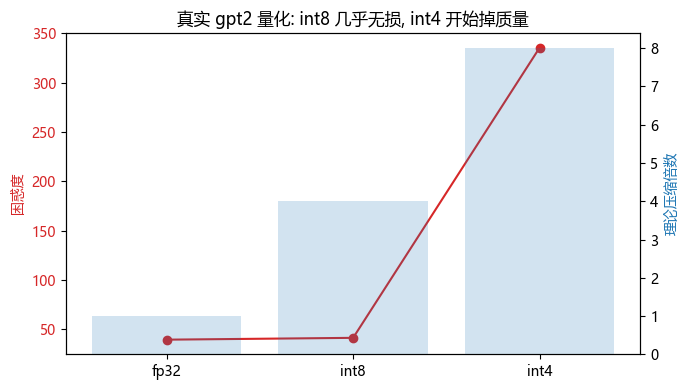

→ int8 困惑度几乎不变 (主流部署默认), int4 明显劣化 (需更聪明的量化, 如分组/GPTQ/AWQ)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
if results:
    bits = [32, 8, 4]; ppl = [results[b] for b in bits]; sizes = [32//b if b<32 else 1 for b in bits]
    fig, ax1 = plt.subplots(figsize=(7,4))
    ax1.plot(['fp32','int8','int4'], ppl, 'o-', color='C3', label='困惑度 (越低越好)')
    ax1.set_ylabel('困惑度', color='C3'); ax1.tick_params(axis='y', labelcolor='C3')
    ax2 = ax1.twinx()
    ax2.bar(['fp32','int8','int4'], [1,4,8], alpha=0.2, color='C0')
    ax2.set_ylabel('理论压缩倍数', color='C0')
    plt.title('真实 gpt2 量化: int8 几乎无损, int4 开始掉质量')
    plt.tight_layout(); plt.show()
    print("→ int8 困惑度几乎不变 (主流部署默认), int4 明显劣化 (需更聪明的量化, 如分组/GPTQ/AWQ)。")

## 4. 反思
你对**真实 gpt2 权重**做了量化, 测了**真实困惑度代价**。带走:
- **int8**: 困惑度几乎不变, 4× 压缩 —— 这就是为什么 int8 是部署默认 (你 quantization 模块的主线)。
- **int4**: 朴素对称量化开始掉质量; 真实 int4 要靠**分组量化 + 校准** (GPTQ/AWQ) 才可用。
- 这只是「权重量化」的最朴素版; 真实工程还有 激活量化、混合精度、per-channel/group scale。

> 量化的本质权衡: **省显存/带宽 vs 精度损失**。int8 是甜点, int4 是前沿战场。